Mounted at /content/drive


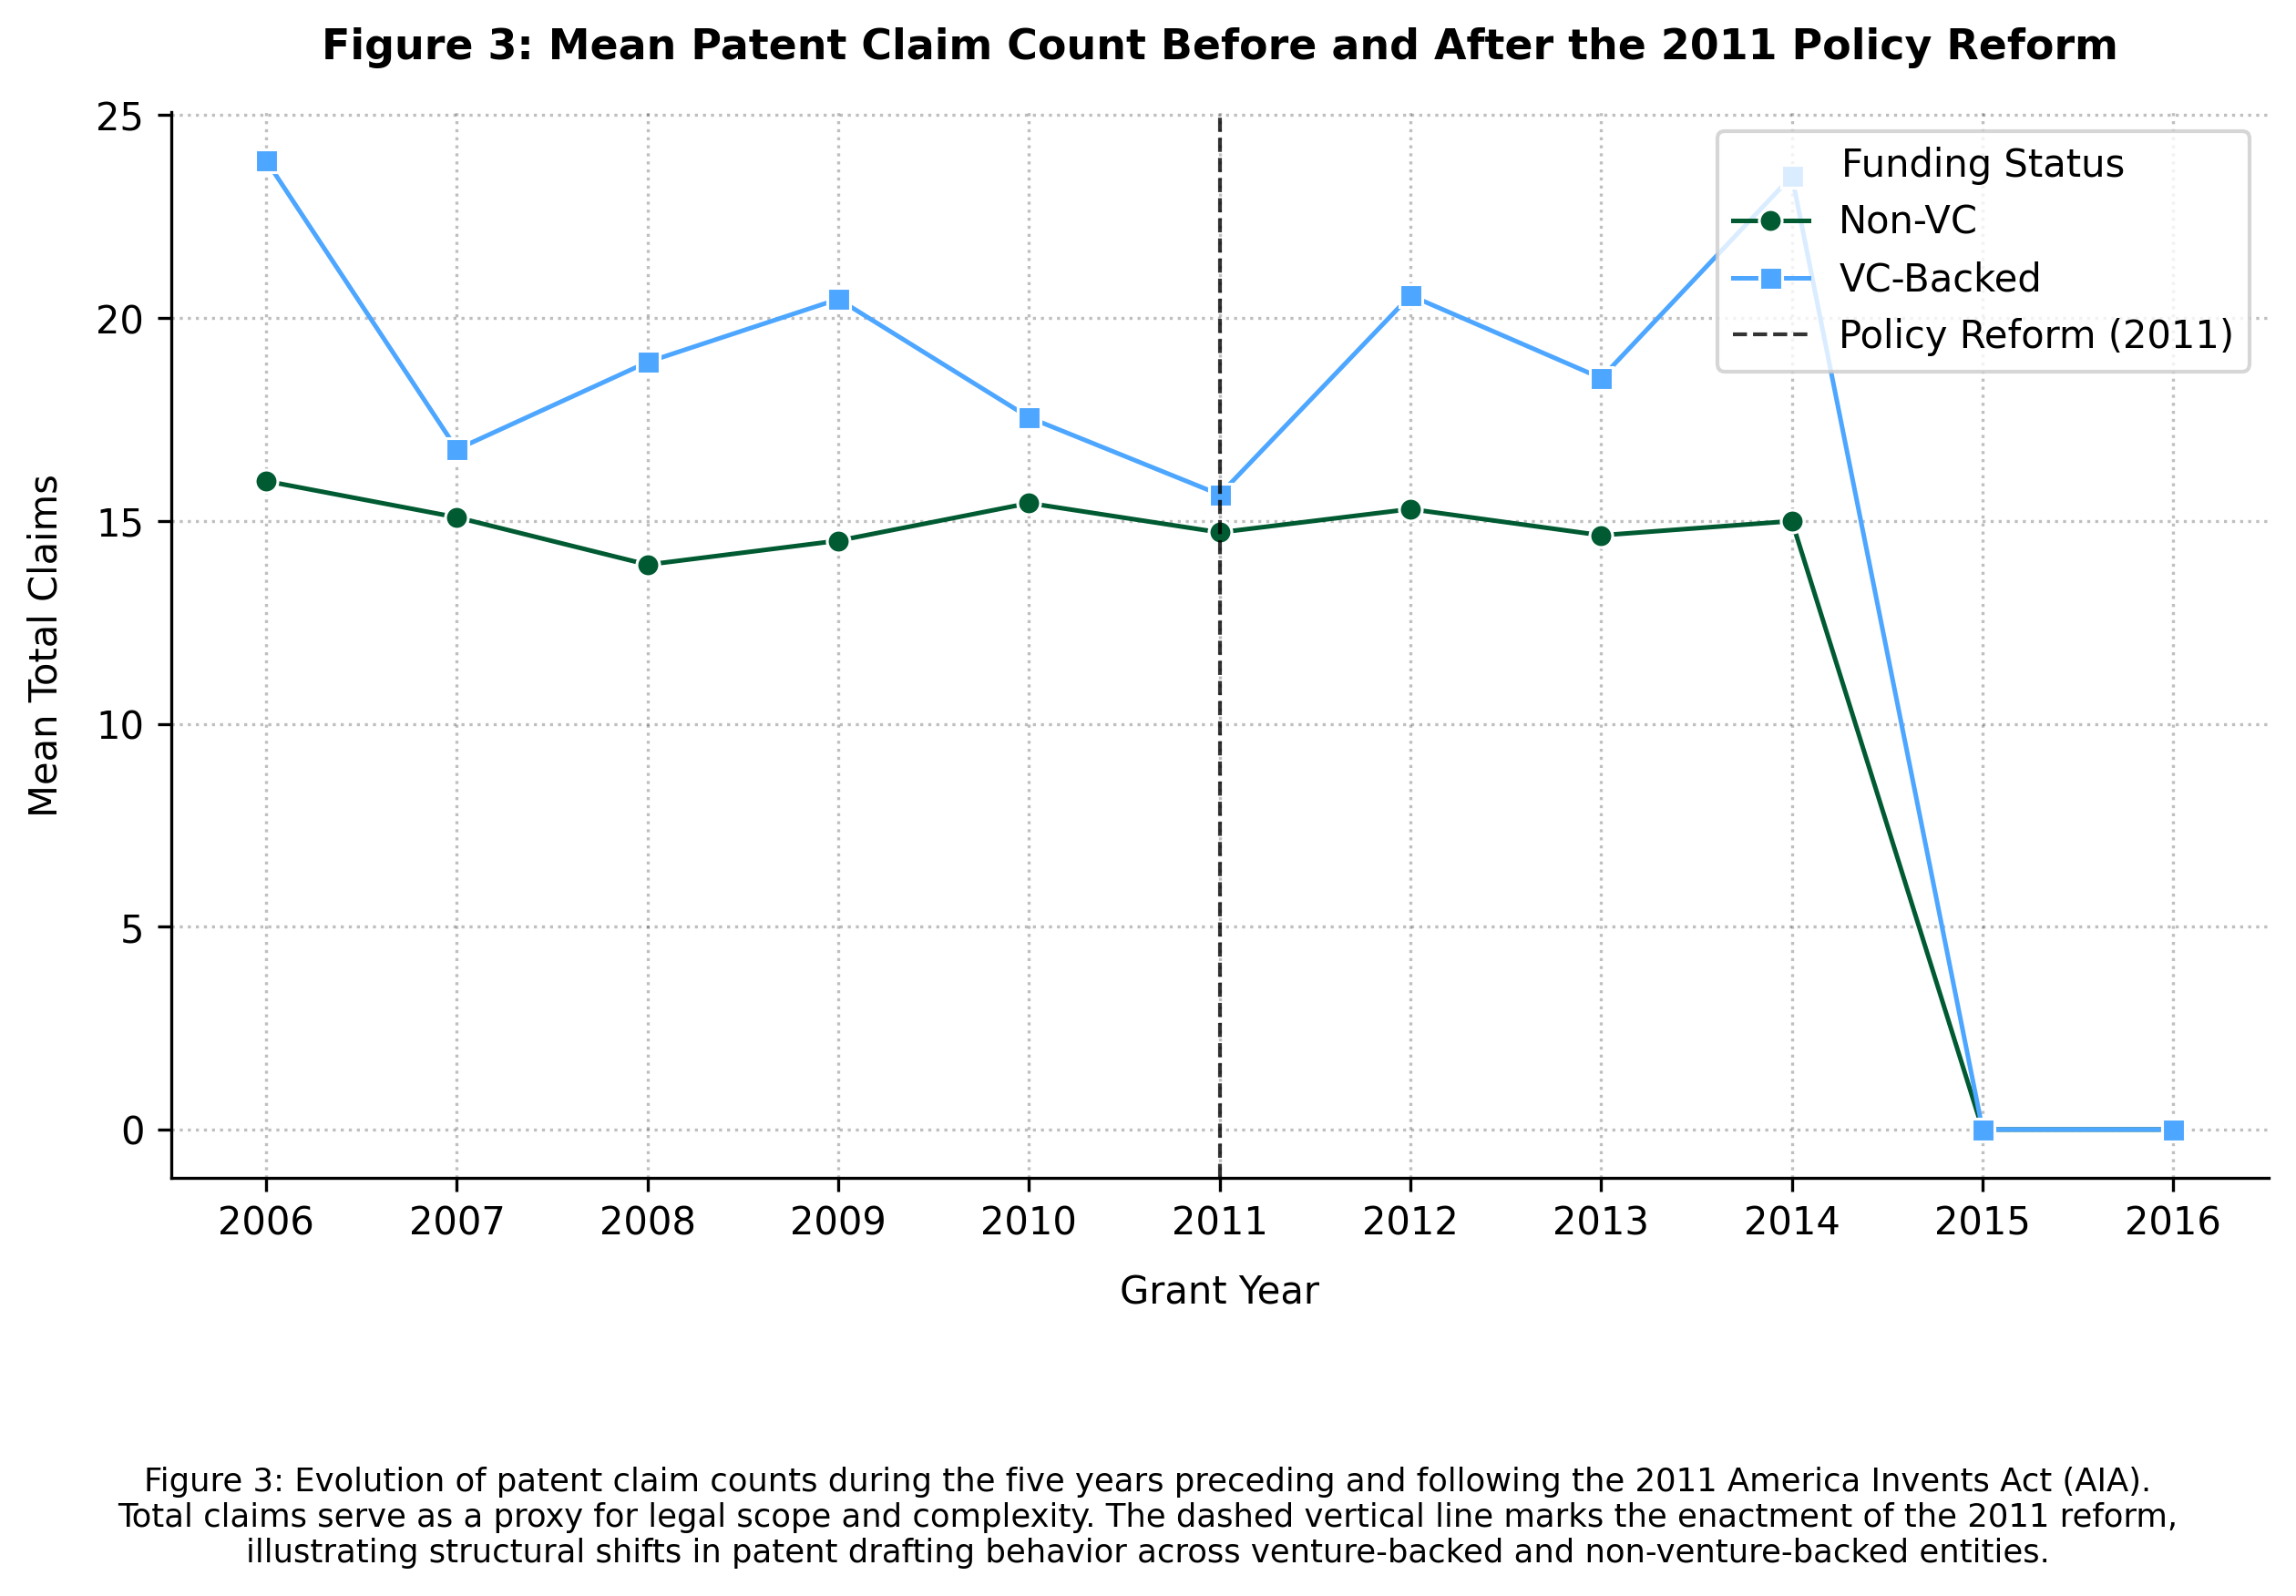

In [2]:
import os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

#figure 3

drive_data_dir = "/content/drive/MyDrive/data"
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

con = duckdb.connect()

# 5 years pre- (2006-2010) and 5 years post- (2012-2016) policy change (2011)
df_claims_trend = con.execute(f"""
    SELECT
        grant_year,
        CASE WHEN vc_backed = 1 THEN 'VC-Backed' ELSE 'Non-VC' END AS vc_status,
        AVG(total_claims) AS mean_claims
    FROM '{parquet_path}'
    WHERE grant_year BETWEEN 2006 AND 2016
    GROUP BY grant_year, vc_backed
    ORDER BY grant_year;
""").df()

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#000000',
    'grid.color': '#000000',
    'grid.alpha': 0.25
})

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

sns.lineplot(
    data=df_claims_trend,
    x='grant_year',
    y='mean_claims',
    hue='vc_status',
    style='vc_status',
    palette={'VC-Backed': '#4da6ff', 'Non-VC': '#005a32'},
    markers={'VC-Backed': 's', 'Non-VC': 'o'},
    dashes=False,
    linewidth=1.2,
    markersize=6,
    ax=ax
)

# vertical line marking the 2011 policy shift (Leahy-Smith America Invents Act)
ax.axvline(2011, color='#000000', linestyle='--', linewidth=1.0, alpha=0.8, label='Policy Reform (2011)')

ax.set_title('Figure 3: Mean Patent Claim Count Before and After the 2011 Policy Reform', fontsize=11, fontweight='bold', pad=14)
ax.set_xlabel('Grant Year', fontsize=10, labelpad=8)
ax.set_ylabel('Mean Total Claims', fontsize=10, labelpad=8)
ax.set_xticks(range(2006, 2017))
ax.grid(True, linestyle=':')

ax.legend(title='Funding Status', frameon=True, loc='upper right')

caption = (
    "Figure 3: Evolution of patent claim counts during the five years preceding and following the 2011 America Invents Act (AIA).\n"
    "Total claims serve as a proxy for legal scope and complexity. The dashed vertical line marks the enactment of the 2011 reform,\n"
    "illustrating structural shifts in patent drafting behavior across venture-backed and non-venture-backed entities."
)
plt.figtext(0.5, -0.15, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

plt.tight_layout()

fig2_path = os.path.join(drive_data_dir, "figure3_claims_policy_trend.png")
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()